# Model Training

Prepare the Training Dataset and experiment with different models for automatically predict the `Test Results` based on a list of patient's features.

# Setup Notebook

## Imports

In [29]:
# Import Standard Libraries
import os
import mlflow
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import multilabel_confusion_matrix, precision_recall_curve
from xgboost import XGBClassifier

# Import Package Modules
from src.general_utils.general_utils import read_configuration
from src.data_preparation.data_preparation import HealthcareDataPreparation
from src.model_training.model_training import ModelTrainer

## Setup Plots Characteristics

In [2]:
# Define Seaborn theme parameters
theme_parameters =  {
    'axes.spines.right': False,
    'axes.spines.top': False,
    'grid.alpha':0.3,
    'figure.figsize': (16, 6),
    'font.family': 'Andale Mono',
    'axes.titlesize': 24,
    'figure.facecolor': '#E5E8E8',
    'axes.facecolor': '#E5E8E8'
}

# Set the theme
sns.set_theme(style='whitegrid',
              palette=sns.color_palette('deep'), 
              rc=theme_parameters)

## Define Configurations

In [3]:
# Retrieve root path
root_path = Path(os.getcwd()).parents[1]

# Read configuration variables
config = read_configuration(root_path / 
                            'configuration' / 
                            'healthcare_classification_config.yaml')

# Extract configuration variables
dataset_config = config['healthcare_dataset_config']
data_pipeline_config = config['healthcare_data_pipeline_config']
model_training_config = config['model_training_config']

[07/31/2024 11:36:05 - general_utils] INFO - read_configuration - Start
[07/31/2024 11:36:05 - general_utils] INFO - read_configuration - Reading /Users/s.porreca/Projects/MediBioticsAI/configuration/healthcare_classification_config.yaml
[07/31/2024 11:36:05 - general_utils] INFO - read_configuration - Configuration file /Users/s.porreca/Projects/MediBioticsAI/configuration/healthcare_classification_config.yaml read successfully
[07/31/2024 11:36:05 - general_utils] INFO - read_configuration - End


# Read Data

## Healthcare Dataset

In [4]:
# Read data
data = pd.read_csv((root_path / '/'.join(dataset_config['data_path'])),
                   parse_dates=dataset_config['date_columns'])

# Data Pipeline

## Define Features and Labels

In [5]:
# Define the features to include
features = data_pipeline_config['features']['numerical'] + \
           data_pipeline_config['features']['categorical']

# Define the label to include
label = data_pipeline_config['labels']

print('Features:')
[print(f'{index + 1}. {feature}') for index, feature in enumerate(features)]
print()
print(f'Labels: {label}')

Features:
1. Age
2. Billing Amount
3. Room Number
4. Gender
5. Blood Type
6. Medical Condition
7. Insurance Provider
8. Admission Type
9. Medication

Labels: ['Test Results']


## Define Data Preparation Pipeline

In [6]:
# Instance the data preparation pipeline object
data_preparation = HealthcareDataPreparation(data_pipeline_config['data_transformations'],
                                             data_pipeline_config['features'])

[07/31/2024 11:36:05 - HealthcareDataPreparation] INFO - __init__ - Initialise object attributes


In [7]:
# Get the training data preparation pipeline
data_preparation_pipeline = data_preparation.build_training_data_preparation_pipeline()

[07/31/2024 11:36:05 - HealthcareDataPreparation] INFO - build_training_data_preparation_pipeline - Start
[07/31/2024 11:36:05 - HealthcareDataPreparation] INFO - build_training_data_preparation_pipeline - Build the Numerical Data Pipeline
[07/31/2024 11:36:05 - data_preparation_utils] INFO - build_numerical_data_pipeline_steps - Start
[07/31/2024 11:36:05 - data_preparation_utils] INFO - build_numerical_data_pipeline_steps - Building steps
[07/31/2024 11:36:05 - data_preparation_utils] INFO - build_numerical_data_pipeline_steps - Skipping Feature Engineering step
[07/31/2024 11:36:05 - data_preparation_utils] INFO - build_numerical_data_pipeline_steps - Adding SimpleImputer Imputation step
[07/31/2024 11:36:05 - data_preparation_utils] INFO - build_numerical_data_pipeline_steps - Adding MinMaxScaler Standardisation step
[07/31/2024 11:36:05 - data_preparation_utils] INFO - build_numerical_data_pipeline_steps - Skipping Normalization step
[07/31/2024 11:36:05 - data_preparation_utils] 

In [8]:
data_preparation_pipeline

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('imputation',
                                                  SimpleImputer(copy=False,
                                                                strategy='median')),
                                                 ('standardisation',
                                                  MinMaxScaler())]),
                                 ['Age', 'Billing Amount', 'Room Number']),
                                ('categorical',
                                 Pipeline(steps=[('imputation',
                                                  SimpleImputer(copy=False,
                                                                fill_value='unknown',
                                                                strategy='constant')),
                                                 ('one_hot_encoding',
                                                  OneHotEncoder())]),
                                 ['Gender', 'Blood Type', 'Medical Condition',
                                  'Insurance Provider', 'Admission Type',
                                  'Medication'])])

## Encode Label

In [9]:
# Encode the label
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(np.ravel(data[label]))

## Train & Test Split

In [10]:
# Define X and y for the training set
X = data[features]
y = encoded_labels

In [11]:
# Retrieve test_size and random_state
test_size = data_pipeline_config['train_test_split']['test_size']
random_state = data_pipeline_config['train_test_split']['random_state']

In [12]:
# Split training data into train and validation
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=test_size,
                                                    random_state=random_state)

# Model Training

## Setup Training

In [13]:
# Set MLflow Experiment
mlflow_experiment_name = model_training_config['mlflow']['experiment_name']

# Set MLflow Experiment
mlflow.set_experiment(mlflow_experiment_name)

<Experiment: artifact_location='file:///Users/s.porreca/Projects/MediBioticsAI/notebooks/healthcare_classification/mlruns/388746619317475161', creation_time=1714156779505, experiment_id='388746619317475161', last_update_time=1714156779505, lifecycle_stage='active', name='Version 1.0.x', tags={}>

In [14]:
# Initialise trained models dictionary
models = {}

# Initialize DataFrame of models performance
performance = pd.DataFrame(columns=model_training_config['metrics'])

## Logistic Regression

In [15]:
# Extract model training configurations
model_name = model_training_config['logistic_regression']['model_name']
mlflow_run_name = model_training_config['logistic_regression']['mlflow_run_name']
metrics = model_training_config['metrics']

In [16]:
# Define the model
model_lr = LogisticRegression()

# Create a ModelTrainer
model_trainer_lr = ModelTrainer(model_name=model_name, 
                                model=model_lr, 
                                data_pipeline=data_preparation_pipeline)

[07/31/2024 11:36:06 - ModelTrainer] INFO - __init__ - Initialise object attributes


In [17]:
# Start an MLflow run
with mlflow.start_run(run_name=mlflow_run_name):

    # Fit the model trainer
    model_trainer_lr.bundle_and_fit_pipeline(X_train, y_train)
    
    # Evaluate the model trainer
    evaluation = model_trainer_lr.evaluate_pipeline(X_test, y_test, metrics)
    
    # Log model's evaluation metrics
    mlflow.log_metrics(evaluation.to_dict()['Value'])
    
    # Log model's features
    mlflow.log_params({'Features': features, 
                       'Labels': label,
                       'Data Transformations': data_pipeline_config['data_transformations'],
                       'Model Initial Hyperparameters': None,
                       'Model Optimised Hyperparameters': None})
    
    # Log the model
    _ = mlflow.sklearn.log_model(
        sk_model=model_trainer_lr.pipeline,
        artifact_path=model_name,
        input_example=X_train.head(1),
        registered_model_name=mlflow_run_name
    )

[07/31/2024 11:36:06 - ModelTrainer] INFO - bundle_and_fit_pipeline - Start
[07/31/2024 11:36:06 - ModelTrainer] INFO - bundle_and_fit_pipeline - Bundle the pipeline
[07/31/2024 11:36:06 - ModelTrainer] INFO - bundle_and_fit_pipeline - Fit the pipeline
[07/31/2024 11:36:06 - ModelTrainer] INFO - bundle_and_fit_pipeline - End
[07/31/2024 11:36:06 - ModelTrainer] INFO - evaluate_pipeline - Start
[07/31/2024 11:36:06 - ModelTrainer] INFO - evaluate_pipeline - Compute predictions
[07/31/2024 11:36:06 - ModelTrainer] INFO - evaluate_pipeline - Evaluate pipeline
[07/31/2024 11:36:06 - model_training_utils] INFO - compute_multi_classification_metrics - Start
[07/31/2024 11:36:06 - model_training_utils] INFO - compute_multi_classification_metrics - Compute metrics            Value
Accuracy    0.32
Precision   0.32
Recall      0.32
F1 Score    0.32
ROC AUC     0.49
[07/31/2024 11:36:06 - model_training_utils] INFO - compute_multi_classification_metrics - End
[07/31/2024 11:36:06 - ModelTrainer]

/Users/s.porreca/Projects/MediBioticsAI/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:406: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/Users/s.porreca/Projects/MediBioticsAI/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:406: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missi

In [18]:
# Update performance dataframe for Model Explainability
performance.loc[mlflow_run_name] = evaluation.Value.values

# Update models dataframe for Model Explainability
models[model_name] = model_trainer_lr.pipeline

## XGBoost Classifier

In [19]:
# Extract model training configurations
model_name = model_training_config['xgboost']['model_name']
mlflow_run_name = model_training_config['xgboost']['mlflow_run_name']
parameters = model_training_config['xgboost']['parameters']
metrics = model_training_config['metrics']

In [20]:
# Define the model
model_xgb = XGBClassifier(**parameters)

# Create a ModelTrainer
model_trainer_xgb = ModelTrainer(model_name=model_name, 
                                 model=model_xgb, 
                                 data_pipeline=data_preparation_pipeline)

[07/31/2024 11:36:09 - ModelTrainer] INFO - __init__ - Initialise object attributes


In [21]:
# Start an MLflow run
with mlflow.start_run(run_name=mlflow_run_name):

    # Fit the model trainer
    model_trainer_xgb.bundle_and_fit_pipeline(X_train, y_train)
    
    # Evaluate the model trainer
    evaluation = model_trainer_xgb.evaluate_pipeline(X_test, y_test, metrics)
    
    # Log model's evaluation metrics
    mlflow.log_metrics(evaluation.to_dict()['Value'])
    
    # Log model's features
    mlflow.log_params({'Features': features, 
                       'Labels': label,
                       'Data Transformations': data_pipeline_config['data_transformations'],
                       'Model Initial Hyperparameters': None,
                       'Model Optimised Hyperparameters': None})
    
    # Log the model
    _ = mlflow.sklearn.log_model(
        sk_model=model_trainer_xgb.pipeline,
        artifact_path=model_name,
        input_example=X_train.head(1),
        registered_model_name=mlflow_run_name
    )

[07/31/2024 11:36:09 - ModelTrainer] INFO - bundle_and_fit_pipeline - Start
[07/31/2024 11:36:09 - ModelTrainer] INFO - bundle_and_fit_pipeline - Bundle the pipeline
[07/31/2024 11:36:09 - ModelTrainer] INFO - bundle_and_fit_pipeline - Fit the pipeline
[07/31/2024 11:36:10 - ModelTrainer] INFO - bundle_and_fit_pipeline - End
[07/31/2024 11:36:10 - ModelTrainer] INFO - evaluate_pipeline - Start
[07/31/2024 11:36:10 - ModelTrainer] INFO - evaluate_pipeline - Compute predictions
[07/31/2024 11:36:10 - ModelTrainer] INFO - evaluate_pipeline - Evaluate pipeline
[07/31/2024 11:36:10 - model_training_utils] INFO - compute_multi_classification_metrics - Start
[07/31/2024 11:36:10 - model_training_utils] INFO - compute_multi_classification_metrics - Compute metrics            Value
Accuracy    0.32
Precision   0.32
Recall      0.32
F1 Score    0.32
ROC AUC     0.50
[07/31/2024 11:36:10 - model_training_utils] INFO - compute_multi_classification_metrics - End
[07/31/2024 11:36:10 - ModelTrainer]

/Users/s.porreca/Projects/MediBioticsAI/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:406: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/Users/s.porreca/Projects/MediBioticsAI/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:406: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missi

In [22]:
# Update performance dataframe for Model Explainability
performance.loc[mlflow_run_name] = evaluation.Value.values

# Update models dataframe for Model Explainability
models[model_name] = model_trainer_xgb.pipeline

# Model Explainability

## Model Comparison

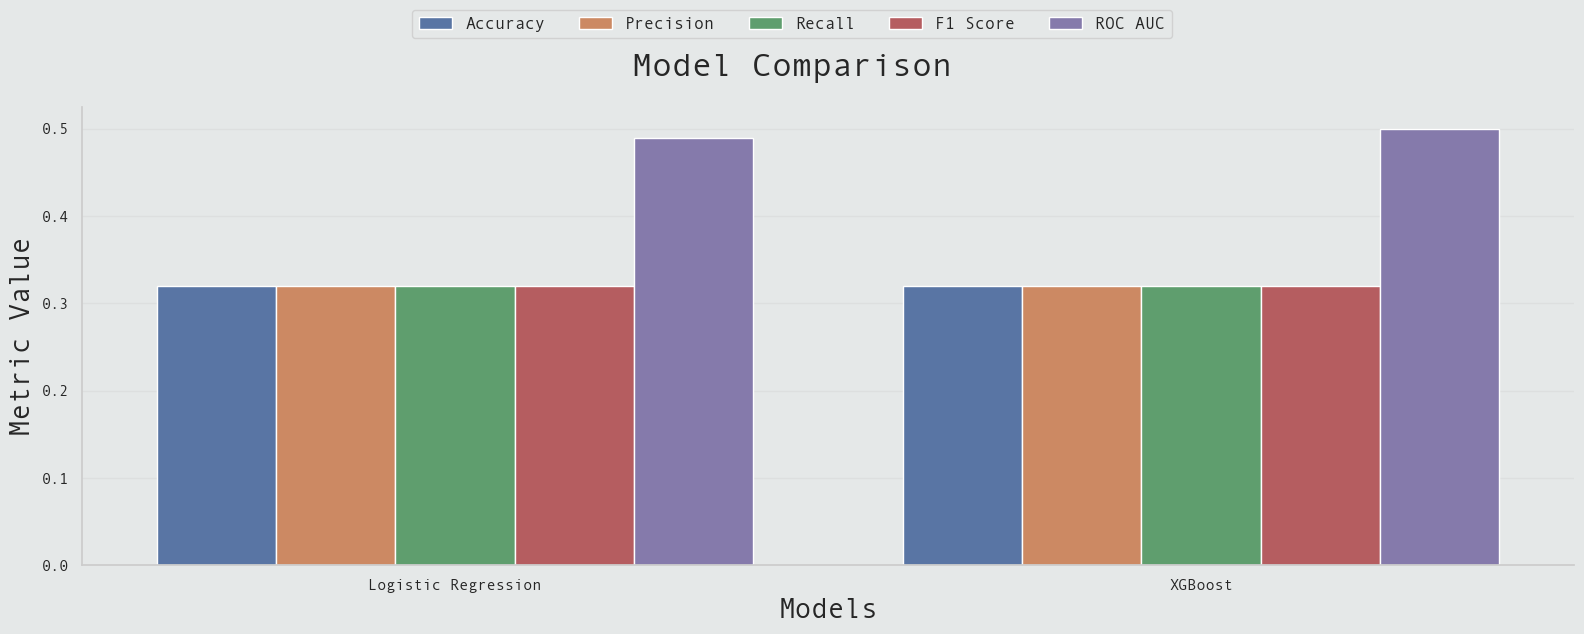

In [23]:
# Create figure
figure = plt.figure(tight_layout=True, figsize=(16, 6))

# Melt the dataframe
melted_performance = pd.melt(performance.reset_index(names='Models'), id_vars='Models', var_name='Metric', value_name='Value')

# Plot models' metrics
ax = sns.barplot(data=melted_performance,
                 x='Models',
                 y='Value', 
                 hue='Metric')


# Set labels
ax.set_xlabel('Models', fontsize=20, weight='bold')
ax.set_ylabel('Metric Value', fontsize=20, weight='bold')

# Retrieve legend information
handles = ax.get_legend_handles_labels()[0]
labels = ax.get_legend_handles_labels()[1]
ax.legend().remove()

# Set the legend
figure.legend(handles, 
              labels, 
              loc='center', 
              bbox_to_anchor=(0.5, 1.03), 
              fontsize=12,
              ncol=len(metrics))

# Set figure Title
figure.suptitle('Model Comparison',
                fontweight='bold',
                fontsize=24)

# Plot with tight layout
plt.tight_layout()

## Confusion Matrix

ValueError: Must pass 2-d input. shape=(3, 2, 2)

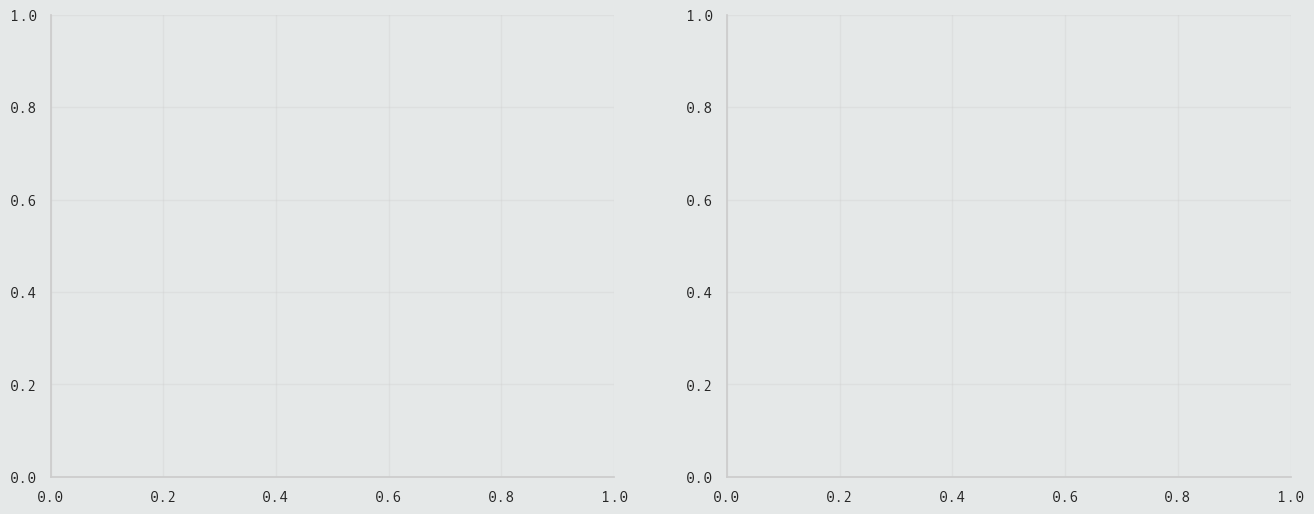

In [30]:
# Define figure and axes
figure, ax = plt.subplots(1, 2, figsize=(16, 6))
ax = ax.flatten()

# Fetch all the trained models
for index, model_name in enumerate(models.keys()):

    # Compute the predictions for the test set
    predictions = models[model_name].predict(X_test)
    
    # Compute confusion matrix
    test_data_confusion_matrix = multilabel_confusion_matrix(y_test, predictions)
    
    # Plot confusion matrix
    sns.heatmap(test_data_confusion_matrix,
                annot=True,
                cmap=sns.light_palette("seagreen", as_cmap=True),
                fmt='g',
                ax=ax[index])
    
    # Set y label
    ax[index].set_ylabel('True Label',
                         fontweight='bold')

    # Set x label
    ax[index].set_xlabel('Predicted Label',
                         fontweight='bold')
    
    # Set the title
    ax[index].set_title(model_name, fontsize=14)

# Define figure title
figure.suptitle('Confusion Matrix',
                fontweight='bold',
                fontsize=24)
    
# Plot with tight layout
plt.tight_layout()

- It predicted quite few label `0` with respect to others &rarr; Check the train-test split

## Precision-Recall Curve

ValueError: multiclass format is not supported

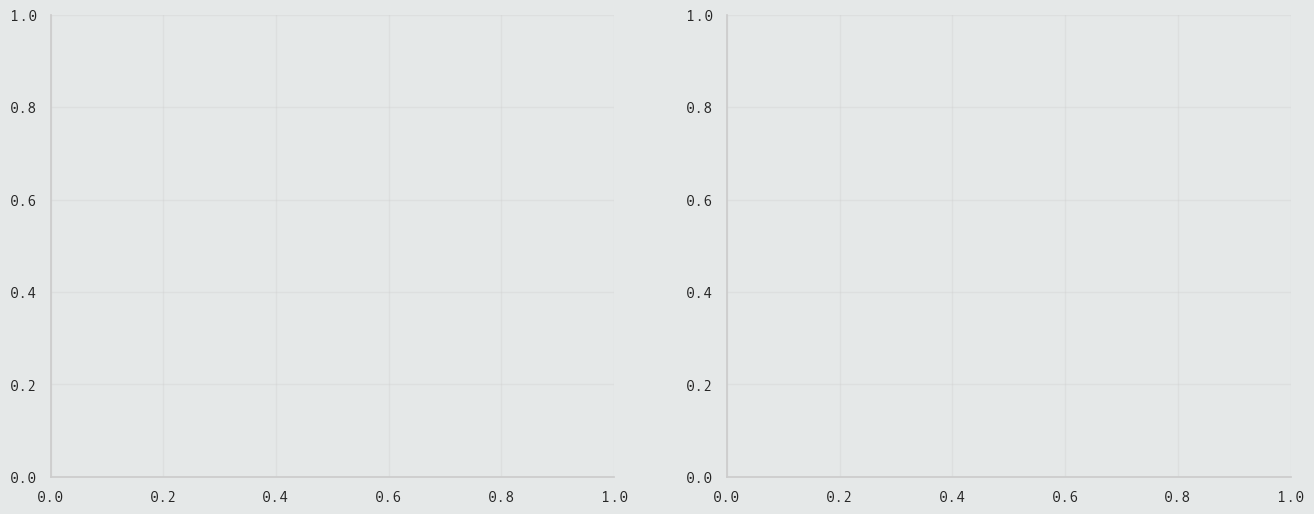

In [28]:
# Define figure and axes
figure, ax = plt.subplots(1, 2, figsize=(16, 6))
ax = ax.flatten()

# Fetch all the trained models
for index, model_name in enumerate(models.keys()):

    # Compute the predictions for the test set
    probabilities = models[model_name].predict_proba(X_test)[:, 1]
    
    # Calculate precision, recall, and thresholds
    precision, recall, _ = precision_recall_curve(y_test, probabilities)
    
    # Plot the Precision-Recall curve
    sns.lineplot(data=pd.DataFrame({'Precision': precision, 'Recall': recall}), 
                 x='Recall', 
                 y='Precision', 
                 ax=ax[index])
    
    # Set y label
    ax[index].set_ylabel('Recall',
                         fontweight='bold')

    # Set x label
    ax[index].set_xlabel('Precision',
                         fontweight='bold')
    
    # Set the title
    ax[index].set_title(model_name, fontsize=14)

# Define figure title
figure.suptitle('Precision-Recall Curve',
                fontweight='bold',
                fontsize=24)
    
# Plot with tight layout
plt.tight_layout()